# Análisis exploratorio de datos - Spanish Sign Language Recognition

## Instalación de librerias

In [ ]:
!pip3 install tensorflow tensorflow-hub numpy opencv-python pandas matplotlib seaborn scikit-learn kagglehub kaggle scikit-image tensorflow.keras

## Importamos las bibliotecas necesarias

In [6]:
import os
from skimage import filters
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from glob import glob
from tqdm import tqdm
from skimage import feature
from skimage.color import rgb2gray
import random
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [16]:
ssl_dataset_path = "/Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/SSLdictionary"

# Funciones para exploración de los datasets

## Exploración básica del dataset

Aquí analizaremos la estructura básica del dataset, indagando sobre el número total de categorías, que serían las señas diferentes, haremos una muestra aleatoría de categorías y un conteo de imágenes en el dataset.

In [17]:
print(f"Explorando dataset: {os.path.basename(ssl_dataset_path)}")
categories = os.listdir(ssl_dataset_path)
categories = [c for c in categories if os.path.isdir(os.path.join(ssl_dataset_path, c))]
print(f"Total de categorías/palabras: {len(categories)}")

print(f"Muestra de categorías: {random.sample(categories, min(10, len(categories)))}")

Explorando dataset: SSLdictionary
Total de categorías/palabras: 19
Muestra de categorías: ['I', 'B', 'N', 'C', 'L', 'T', 'G', 'S', 'F', 'M']


### Contamos la cantidad de imágenes

In [20]:
def count_images(dataset_path, categories):
    category_counts = {}
    total_images = 0
    image_extensions = ['.jpg']
    
    for category in categories:
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            files = os.listdir(category_path)
            image_files = [f for f in files if os.path.splitext(f.lower())[1] in image_extensions]
            category_counts[category] = len(image_files)
            total_images += len(image_files)
    
    return category_counts, total_images

category_counts, total_images = count_images(ssl_dataset_path, categories)
print(f"Total de imágenes: {total_images}")

Total de imágenes: 1998


## Análisis de propiedades básicas de imágenes

Solo exploraremos las propiedades fundamentales de las imágenes como tamaño, color, brillo, etc

In [21]:
def analyze_image_properties(dataset_path, categories, samples_per_category=2, max_categories=15):
    image_extensions = ['.jpg']
    image_properties = []
    
    np.random.seed(42)
    selected_categories = np.random.choice(categories, 
                                          min(max_categories, len(categories)), 
                                          replace=False)
    
    for category in selected_categories:
        category_path = os.path.join(dataset_path, category)
        files = os.listdir(category_path)
        image_files = [f for f in files if os.path.splitext(f.lower())[1] in image_extensions]
        
        if not image_files:
            continue
            
        selected_files = np.random.choice(image_files, 
                                         min(samples_per_category, len(image_files)), 
                                         replace=False)
        
        for file in selected_files:
            file_path = os.path.join(category_path, file)
            try:
                img = cv2.imread(file_path)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                
                height, width = img.shape[:2]
                channels = img.shape[2] if len(img.shape) > 2 else 1
                
                
                mean_color = np.mean(img_rgb, axis=(0, 1))
                std_color = np.std(img_rgb, axis=(0, 1))
                
                contrast = np.std(img_gray)
                
                brightness = np.mean(img_gray)
                
                
                edges = cv2.Canny(img_gray, 100, 200)
                edge_density = np.sum(edges > 0) / (height * width)
                
                
                hist_r = cv2.calcHist([img_rgb], [0], None, [8], [0, 256])
                hist_g = cv2.calcHist([img_rgb], [1], None, [8], [0, 256])
                hist_b = cv2.calcHist([img_rgb], [2], None, [8], [0, 256])
                
                
                hist_r = hist_r.flatten() / np.sum(hist_r)
                hist_g = hist_g.flatten() / np.sum(hist_g)
                hist_b = hist_b.flatten() / np.sum(hist_b)
                
                
                image_properties.append({
                    'category': category,
                    'file': file,
                    'path': file_path,
                    'height': height,
                    'width': width,
                    'aspect_ratio': width / height,
                    'channels': channels,
                    'mean_r': mean_color[0],
                    'mean_g': mean_color[1],
                    'mean_b': mean_color[2],
                    'std_r': std_color[0],
                    'std_g': std_color[1],
                    'std_b': std_color[2],
                    'brightness': brightness,
                    'contrast': contrast,
                    'edge_density': edge_density,
                    'hist_r': hist_r,
                    'hist_g': hist_g,
                    'hist_b': hist_b,
                    'image': img_rgb 
                })
                
            except Exception as e:
                print(f"Error procesando {file_path}: {e}")
    
    return image_properties

image_properties = analyze_image_properties(ssl_dataset_path, categories)
print(f"Analizadas {len(image_properties)} imágenes")

Analizadas 30 imágenes


In [22]:
df_properties = pd.DataFrame([{k: v for k, v in item.items() if k != 'image' and 
                               not k.startswith('hist')} 
                              for item in image_properties])

print("\nEstadísticas de dimensiones de imágenes:")
print(df_properties[['height', 'width', 'aspect_ratio']].describe())

print("\nEstadísticas de color:")
print(df_properties[['mean_r', 'mean_g', 'mean_b', 'brightness', 'contrast']].describe())


Estadísticas de dimensiones de imágenes:
       height   width  aspect_ratio
count    30.0    30.0     30.000000
mean   2408.0  4288.0      1.780731
std       0.0     0.0      0.000000
min    2408.0  4288.0      1.780731
25%    2408.0  4288.0      1.780731
50%    2408.0  4288.0      1.780731
75%    2408.0  4288.0      1.780731
max    2408.0  4288.0      1.780731

Estadísticas de color:
           mean_r      mean_g      mean_b  brightness   contrast
count   30.000000   30.000000   30.000000   30.000000  30.000000
mean   130.278439  128.129285  126.321090  128.535293  23.919940
std      1.404231    1.906918    2.706735    1.705122   3.619883
min    127.114193  121.744788  116.389294  122.767255  17.882411
25%    129.542672  126.808351  125.225199  127.434907  21.584750
50%    130.660172  128.021152  126.926922  128.555664  23.280782
75%    131.375690  129.822800  127.713801  130.036563  26.190937
max    132.583848  130.870192  130.335754  131.150808  31.567094


## Visualización de imágenes de muestra

Mostraremos ejemplos de imágenes del dataset para entender visualmente el contenido (aunque ya se sepa de lo que trata)

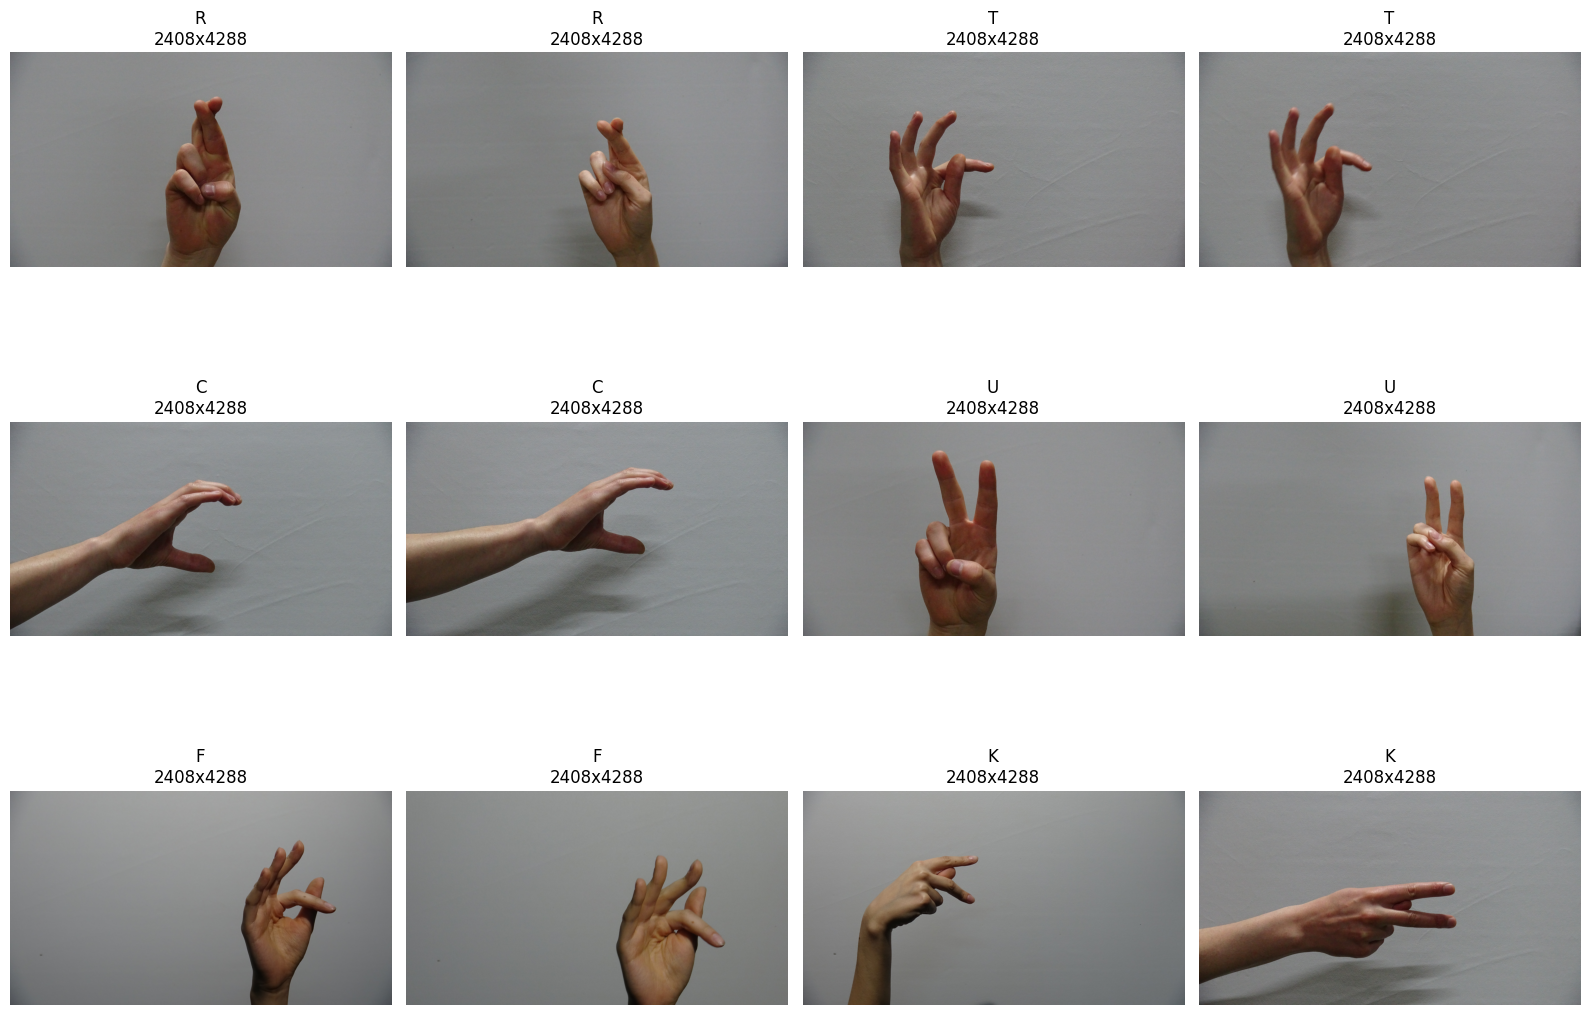

In [23]:
def plot_sample_images(image_properties, rows=3, cols=4):
    plt.figure(figsize=(16, 12))
    samples = min(rows * cols, len(image_properties))
    
    for i in range(samples):
        plt.subplot(rows, cols, i+1)
        plt.imshow(image_properties[i]['image'])
        plt.title(f"{image_properties[i]['category']}\n{image_properties[i]['height']}x{image_properties[i]['width']}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

plot_sample_images(image_properties)

## Análisis de dimensiones y resolución

Esto lo haremos principalmente para entender la variabilidad y la consistencia de las imágenes

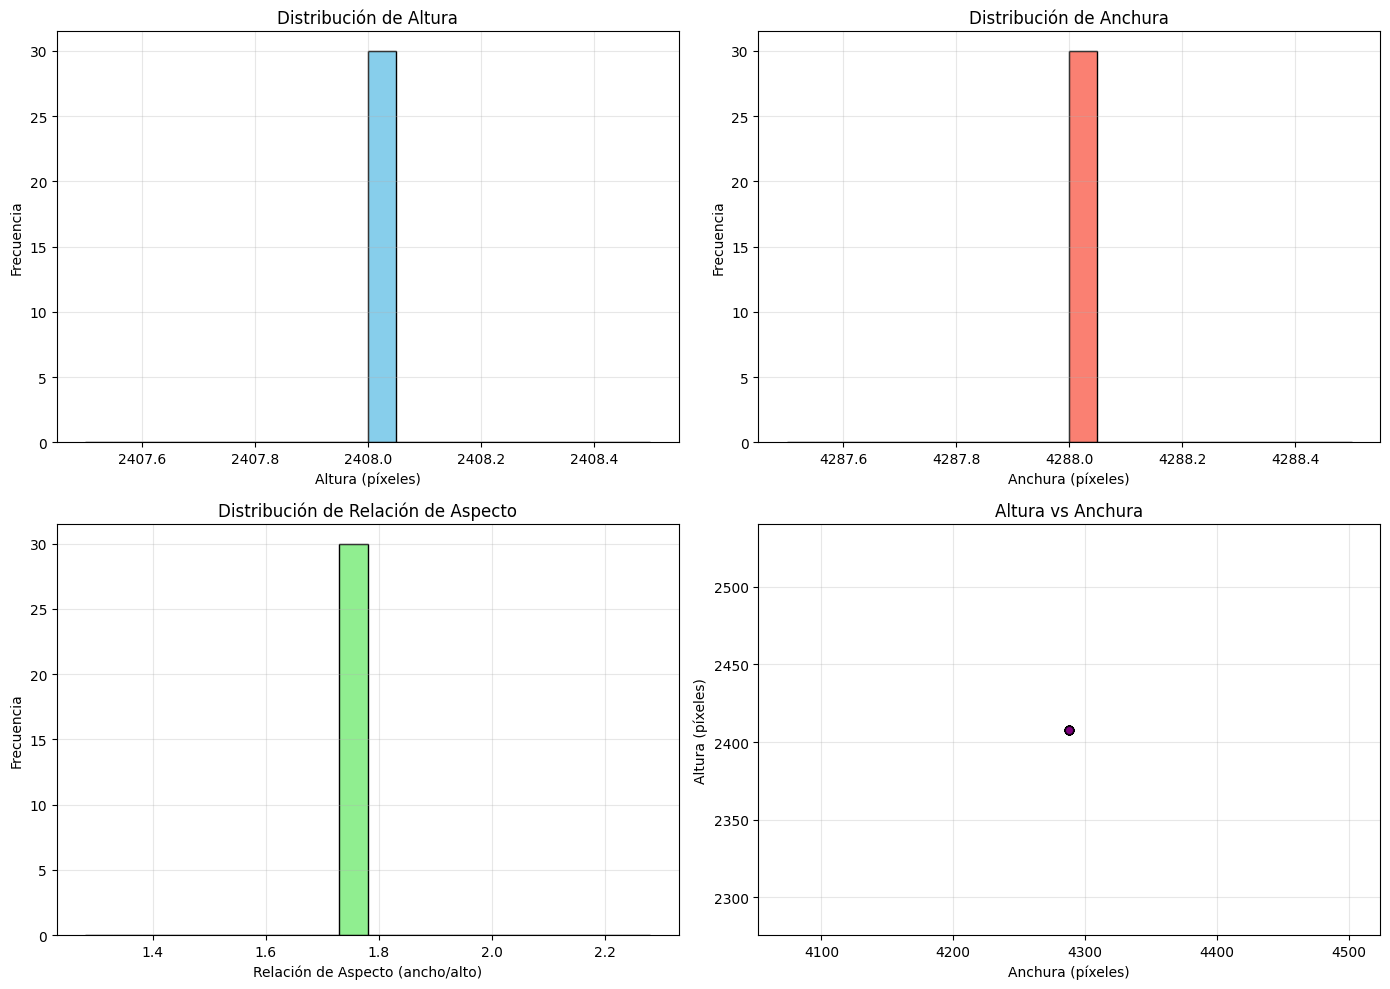

In [24]:
plt.figure(figsize=(14, 10))

# Histograma de altura
plt.subplot(2, 2, 1)
plt.hist(df_properties['height'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de Altura', fontsize=12)
plt.xlabel('Altura (píxeles)')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)

# Histograma de anchura
plt.subplot(2, 2, 2)
plt.hist(df_properties['width'], bins=20, color='salmon', edgecolor='black')
plt.title('Distribución de Anchura', fontsize=12)
plt.xlabel('Anchura (píxeles)')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)

# Histograma de relación de aspecto
plt.subplot(2, 2, 3)
plt.hist(df_properties['aspect_ratio'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribución de Relación de Aspecto', fontsize=12)
plt.xlabel('Relación de Aspecto (ancho/alto)')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)

# Gráfico de dispersión altura vs anchura
plt.subplot(2, 2, 4)
plt.scatter(df_properties['width'], df_properties['height'], 
            alpha=0.7, c='purple', edgecolor='black')
plt.title('Altura vs Anchura', fontsize=12)
plt.xlabel('Anchura (píxeles)')
plt.ylabel('Altura (píxeles)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Análisis de propiedades de color

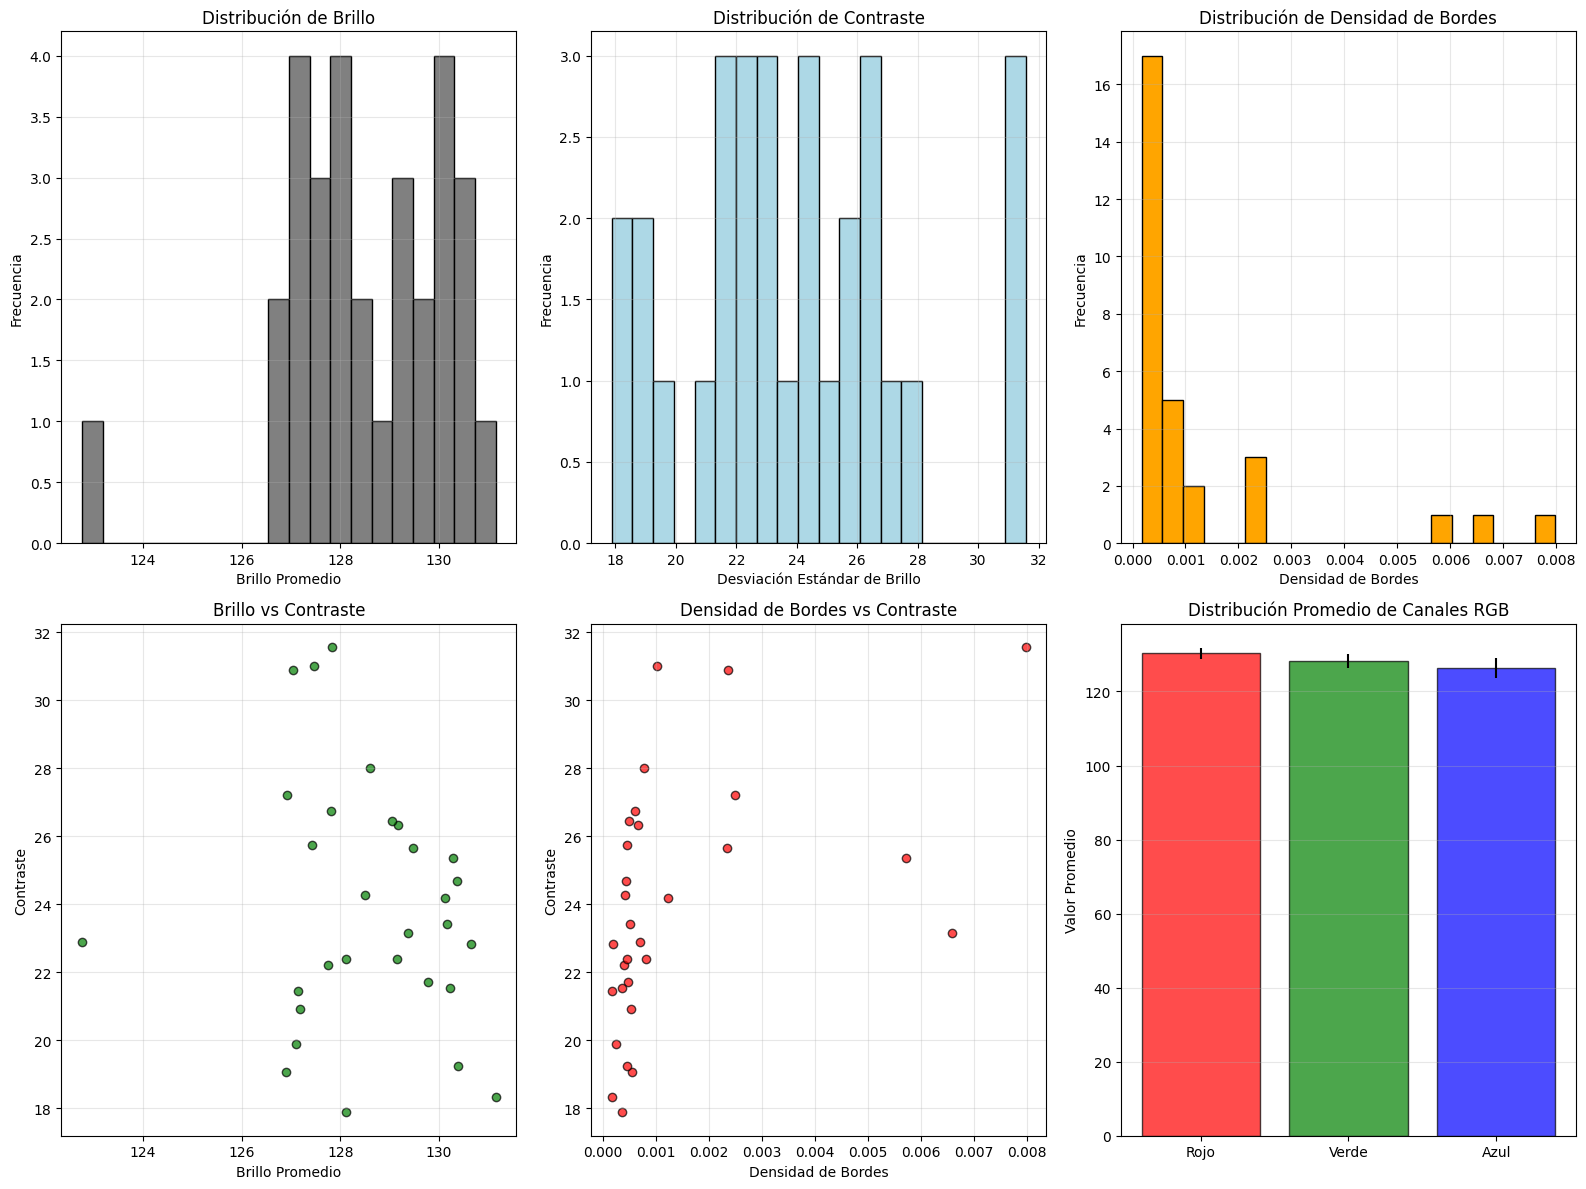

In [25]:
plt.figure(figsize=(16, 12))

# Histograma de brillo
plt.subplot(2, 3, 1)
plt.hist(df_properties['brightness'], bins=20, color='gray', edgecolor='black')
plt.title('Distribución de Brillo', fontsize=12)
plt.xlabel('Brillo Promedio')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)

# Histograma de contraste
plt.subplot(2, 3, 2)
plt.hist(df_properties['contrast'], bins=20, color='lightblue', edgecolor='black')
plt.title('Distribución de Contraste', fontsize=12)
plt.xlabel('Desviación Estándar de Brillo')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)

# Histograma de densidad de bordes
plt.subplot(2, 3, 3)
plt.hist(df_properties['edge_density'], bins=20, color='orange', edgecolor='black')
plt.title('Distribución de Densidad de Bordes', fontsize=12)
plt.xlabel('Densidad de Bordes')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)

# Gráfico de dispersión brillo vs contraste
plt.subplot(2, 3, 4)
plt.scatter(df_properties['brightness'], df_properties['contrast'], 
            alpha=0.7, c='green', edgecolor='black')
plt.title('Brillo vs Contraste', fontsize=12)
plt.xlabel('Brillo Promedio')
plt.ylabel('Contraste')
plt.grid(alpha=0.3)

# Gráfico de dispersión densidad de bordes vs contraste
plt.subplot(2, 3, 5)
plt.scatter(df_properties['edge_density'], df_properties['contrast'], 
            alpha=0.7, c='red', edgecolor='black')
plt.title('Densidad de Bordes vs Contraste', fontsize=12)
plt.xlabel('Densidad de Bordes')
plt.ylabel('Contraste')
plt.grid(alpha=0.3)

# Distribución RGB promedio
plt.subplot(2, 3, 6)
# Creamos un gráfico de barras para cada canal de color
categories = ['Rojo', 'Verde', 'Azul']
means = [df_properties['mean_r'].mean(), 
         df_properties['mean_g'].mean(), 
         df_properties['mean_b'].mean()]
stds = [df_properties['mean_r'].std(), 
        df_properties['mean_g'].std(), 
        df_properties['mean_b'].std()]

plt.bar(categories, means, yerr=stds, alpha=0.7, 
        color=['red', 'green', 'blue'], edgecolor='black')
plt.title('Distribución Promedio de Canales RGB', fontsize=12)
plt.ylabel('Valor Promedio')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Análisis de histogramas de color

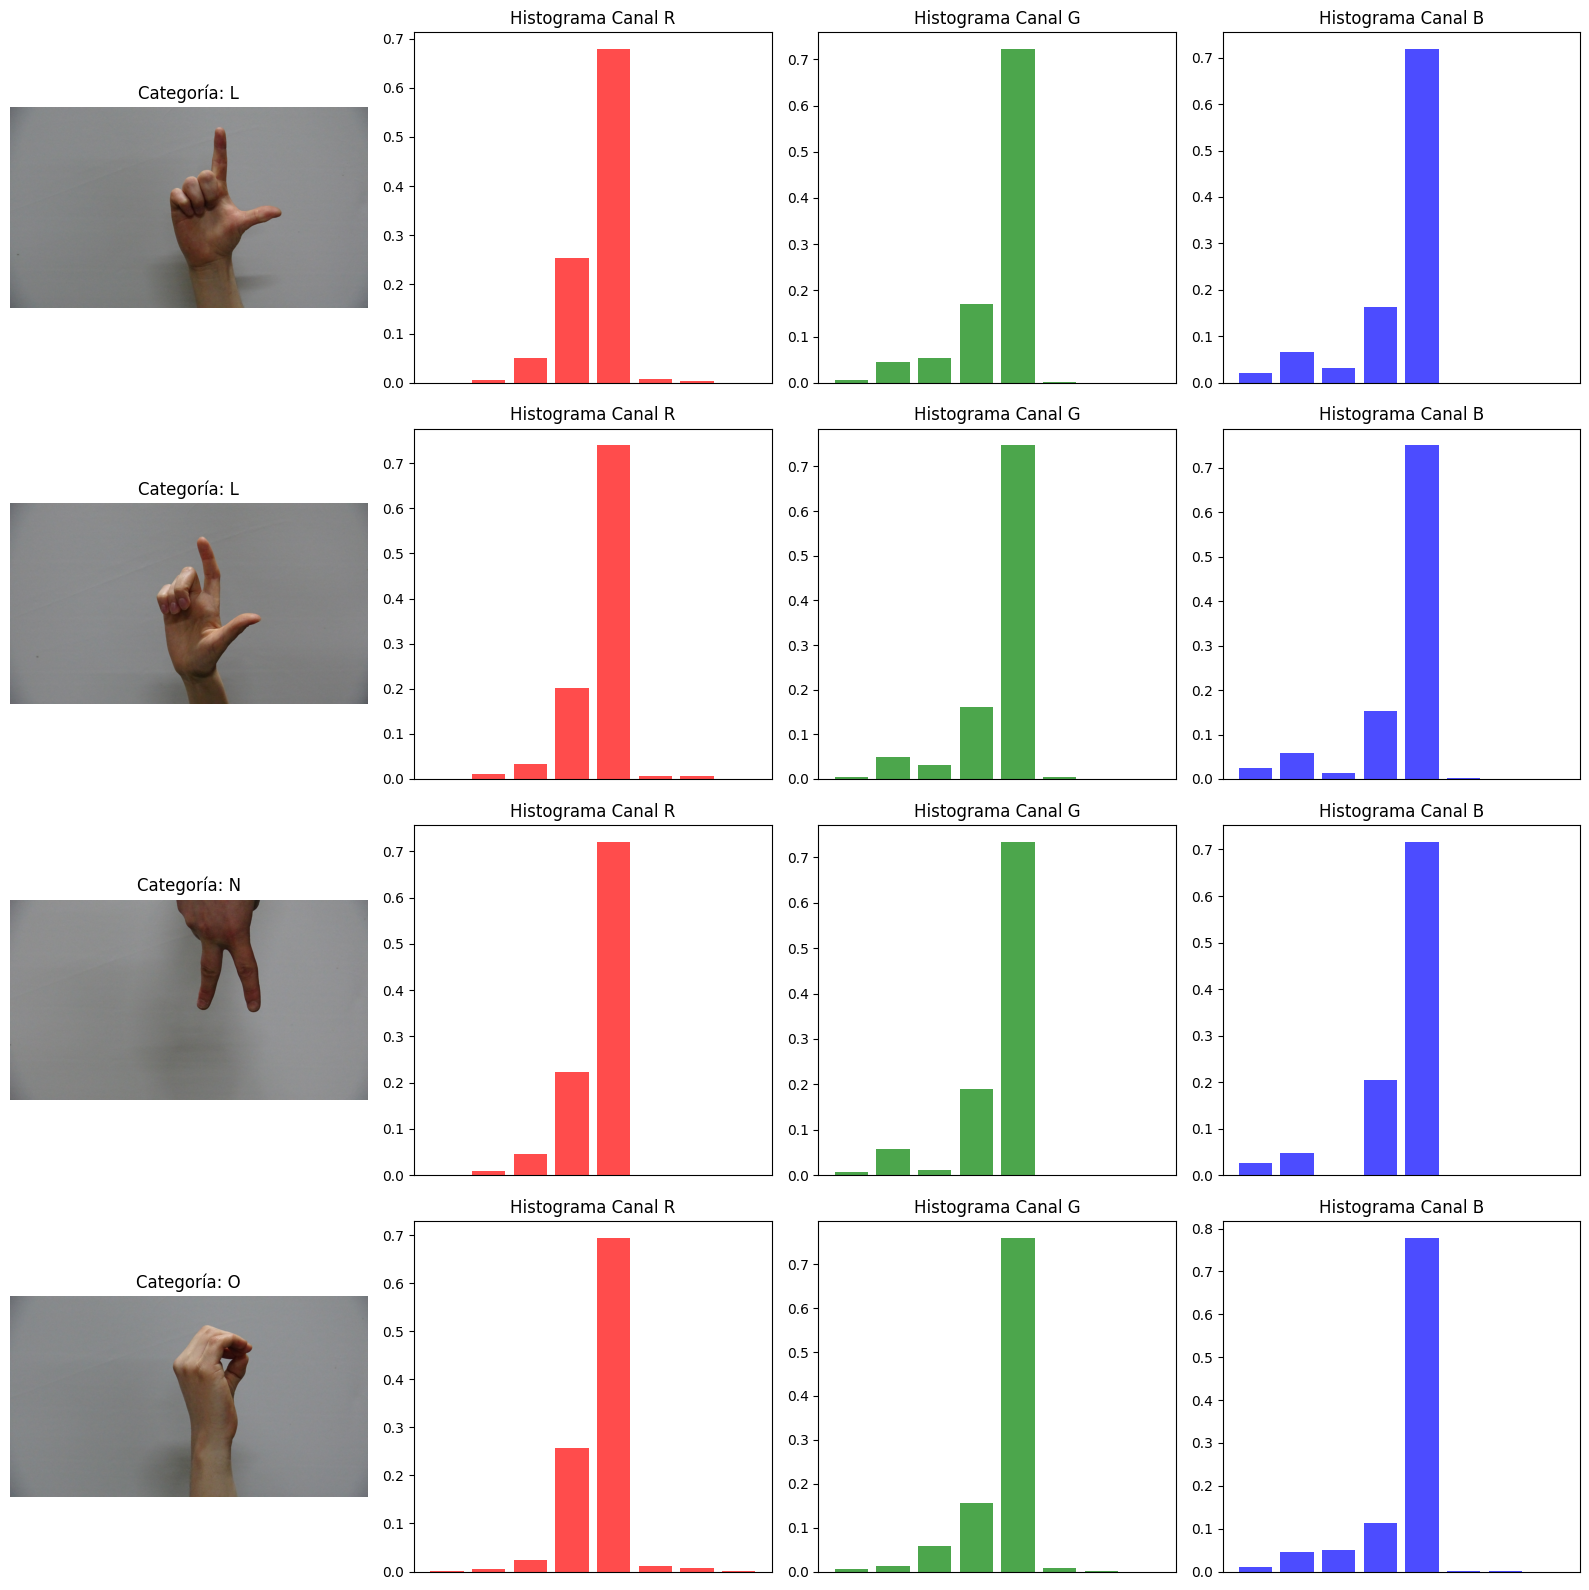

In [26]:
def plot_color_histograms(image_properties, num_samples=4):
    samples = random.sample(image_properties, min(num_samples, len(image_properties)))
    
    plt.figure(figsize=(16, 4 * num_samples))
    
    for i, sample in enumerate(samples):
        # Imagen original
        plt.subplot(num_samples, 4, i*4 + 1)
        plt.imshow(sample['image'])
        plt.title(f"Categoría: {sample['category']}")
        plt.axis('off')
        
        # Histograma canal R
        plt.subplot(num_samples, 4, i*4 + 2)
        plt.bar(range(len(sample['hist_r'])), sample['hist_r'], color='red', alpha=0.7)
        plt.title('Histograma Canal R')
        plt.xticks([])
        
        # Histograma canal G
        plt.subplot(num_samples, 4, i*4 + 3)
        plt.bar(range(len(sample['hist_g'])), sample['hist_g'], color='green', alpha=0.7)
        plt.title('Histograma Canal G')
        plt.xticks([])
        
        # Histograma canal B
        plt.subplot(num_samples, 4, i*4 + 4)
        plt.bar(range(len(sample['hist_b'])), sample['hist_b'], color='blue', alpha=0.7)
        plt.title('Histograma Canal B')
        plt.xticks([])
    
    plt.tight_layout()
    plt.show()

# Visualizamos histogramas de color para algunas imágenes
plot_color_histograms(image_properties)

## Detección y visualización de bordes

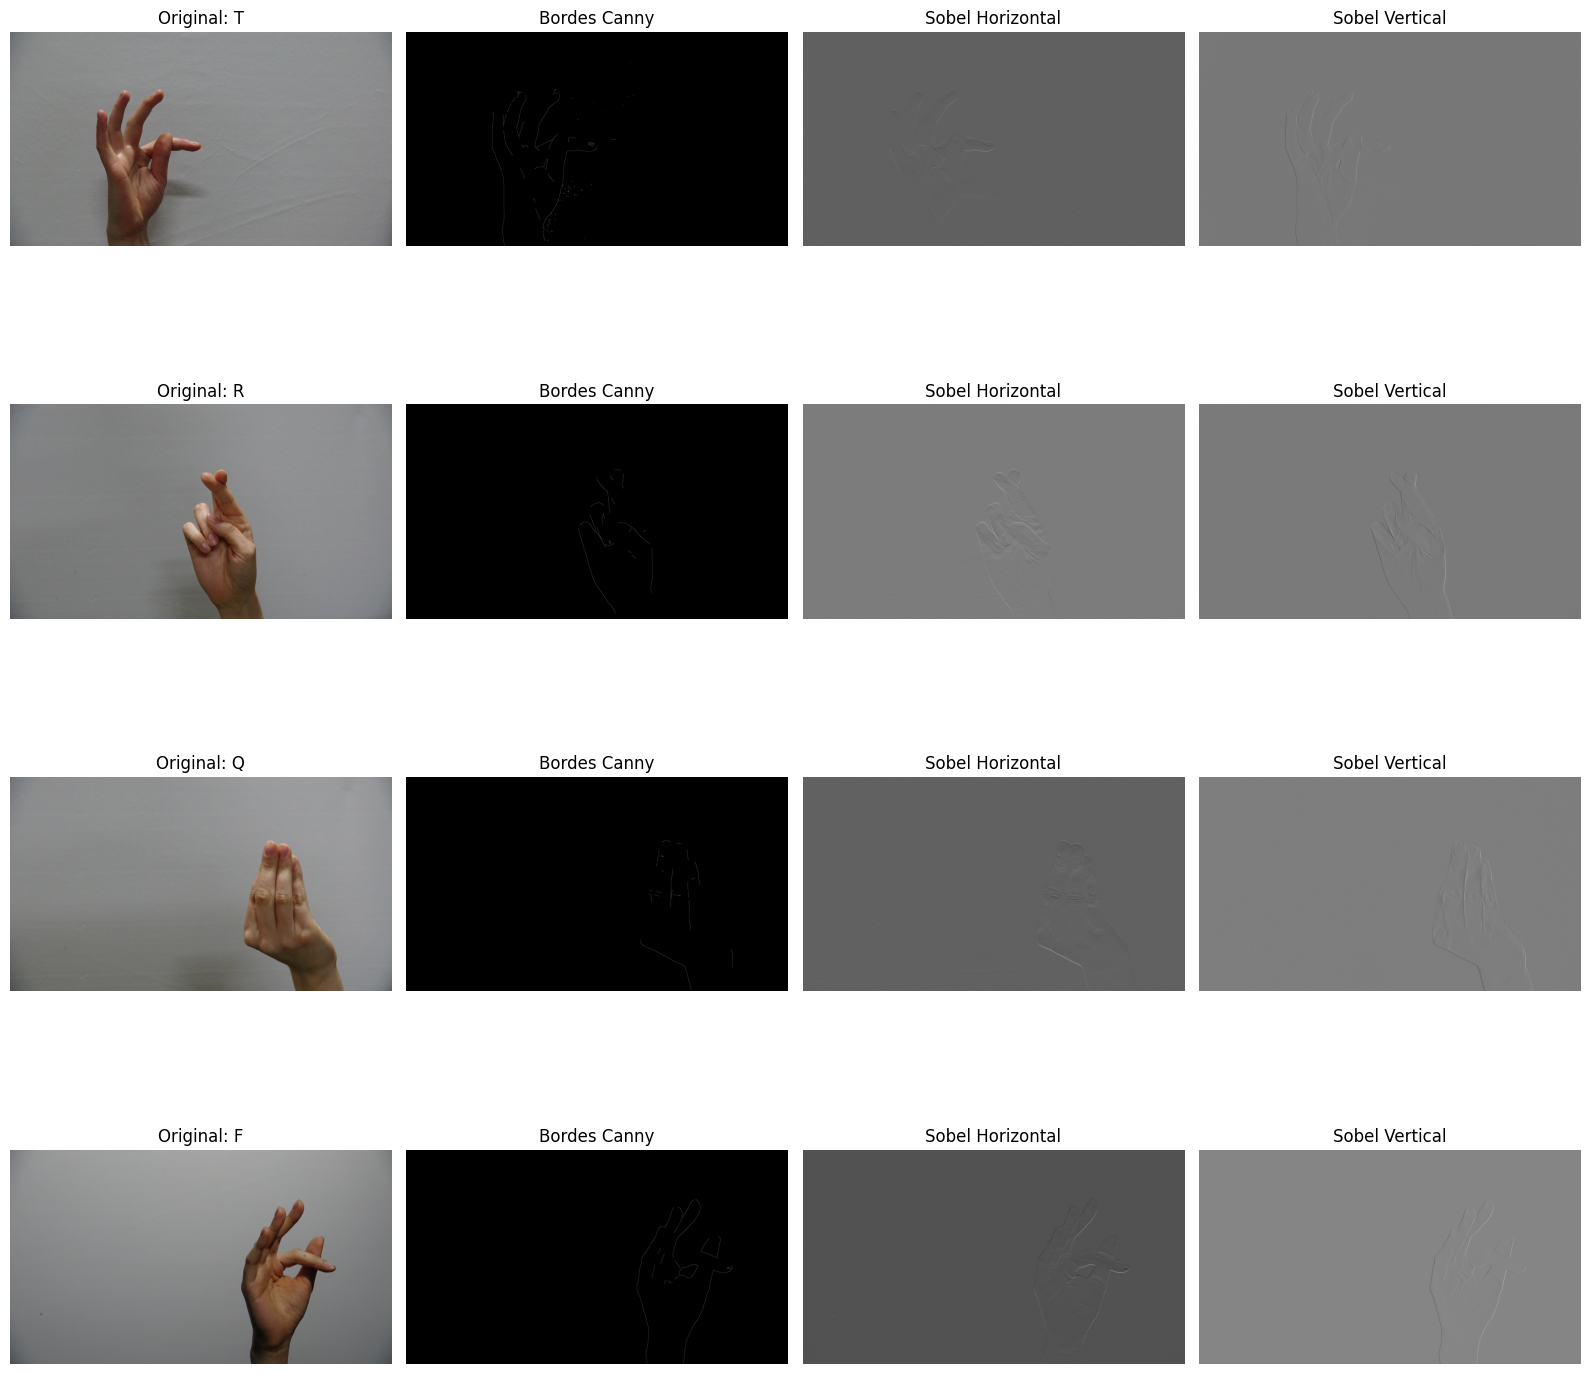

In [ ]:
def plot_edge_detection(image_properties, num_samples=4):
    samples = random.sample(image_properties, min(num_samples, len(image_properties)))
    
    plt.figure(figsize=(16, 4 * num_samples))
    
    for i, sample in enumerate(samples):
        img = sample['image']
        img_gray = rgb2gray(img)
        
        edges_canny = feature.canny(img_gray, sigma=2)
        edges_sobel_h = filters.sobel_h(img_gray)
        edges_sobel_v = filters.sobel_v(img_gray)
        
        # Imagen original
        plt.subplot(num_samples, 4, i*4 + 1)
        plt.imshow(img)
        plt.title(f"Original: {sample['category']}")
        plt.axis('off')
        
        # Bordes Canny
        plt.subplot(num_samples, 4, i*4 + 2)
        plt.imshow(edges_canny, cmap='gray')
        plt.title('Bordes Canny')
        plt.axis('off')
        
        # Bordes Sobel Horizontal
        plt.subplot(num_samples, 4, i*4 + 3)
        plt.imshow(edges_sobel_h, cmap='gray')
        plt.title('Sobel Horizontal')
        plt.axis('off')
        
        # Bordes Sobel Vertical
        plt.subplot(num_samples, 4, i*4 + 4)
        plt.imshow(edges_sobel_v, cmap='gray')
        plt.title('Sobel Vertical')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

plot_edge_detection(image_properties)

## Extracción de características con CNN

Extraeremos características numéricas de las imágenes para un análisis cuantitativo

In [33]:
def extract_basic_features(image_properties, num_samples=30):
    samples = random.sample(image_properties, min(num_samples, len(image_properties)))
    
    features = []
    labels = []
    
    for sample in samples:
        img = sample['image']
        img_resized = cv2.resize(img, (224, 224))
    
        features_basic = []
        
        for channel in range(3):
            channel_data = img_resized[:,:,channel]
            features_basic.extend([
                np.mean(channel_data),
                np.std(channel_data),
                np.percentile(channel_data, 25),
                np.percentile(channel_data, 75)
            ])
        
        # Características de textura usando gradientes
        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
        gradients_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gradients_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        
        features_basic.extend([
            np.mean(np.abs(gradients_x)),
            np.std(np.abs(gradients_x)),
            np.mean(np.abs(gradients_y)),
            np.std(np.abs(gradients_y))
        ])
        
        # Características de forma usando bordes
        edges = cv2.Canny(gray, 100, 200)
        features_basic.extend([
            np.mean(edges),
            np.sum(edges > 0) / edges.size
        ])
        
        features.append(features_basic)
        labels.append(sample['category'])
    
    return np.array(features), labels

# Extraemos características básicas
basic_features, feature_labels = extract_basic_features(image_properties)

print(f"Características extraídas: {basic_features.shape}")

Características extraídas: (30, 18)


## Visualización de estas características de alto nivel

Características extraídas: (30, 18)


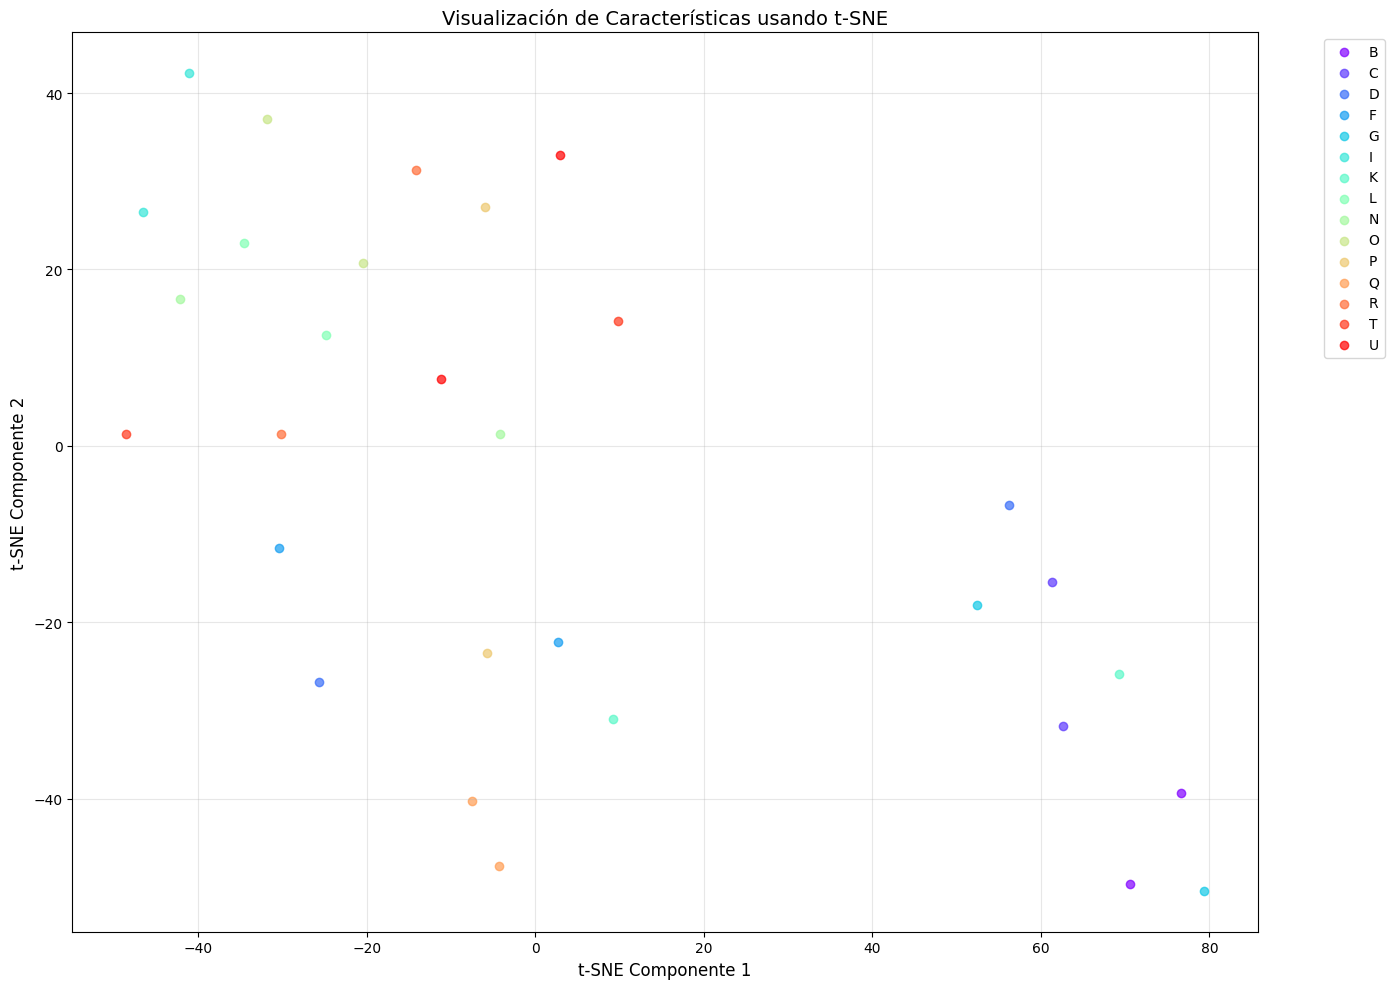

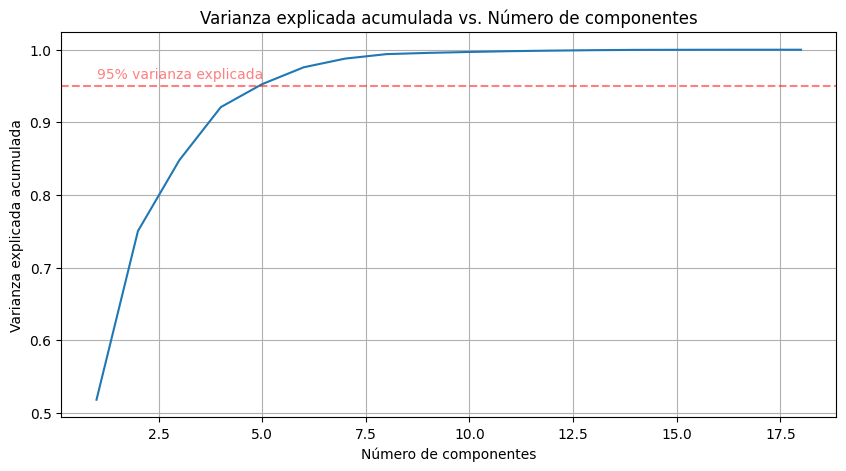


Información sobre la reducción de dimensionalidad:
Número de características originales: 18
Número de componentes PCA: 18
Varianza explicada con 18 componentes: 1.0000
Componentes necesarios para explicar 95% de la varianza: 5


In [ ]:
def visualize_feature_space(features, labels):
    # Reducimos dimensionalidad con PCA
    n_components = min(50, features.shape[1])
    pca = PCA(n_components=n_components)
    features_pca = pca.fit_transform(features)
    
    # Ajustamos la perplexidad basada en el número de muestras
    n_samples = features.shape[0]
    perplexity = min(30, n_samples // 4)  # Ajustamos la perplexidad según el tamaño de los datos
    
    # Aplicamos t-SNE para visualización con perplexidad ajustada
    if n_samples >= 5:  # t-SNE necesita al menos 5 muestras
        tsne = TSNE(n_components=2, random_state=42, perplexity=max(5, perplexity))
        features_2d = tsne.fit_transform(features_pca)
        method = 't-SNE'
    else:
        # Si hay muy pocas muestras, usamos solo PCA
        features_2d = features_pca[:, :2]
        method = 'PCA'
    
    # Convertimos a DataFrame para facilitar graficado
    df_vis = pd.DataFrame({
        'x': features_2d[:, 0],
        'y': features_2d[:, 1],
        'category': labels
    })
    
    # Graficamos
    plt.figure(figsize=(14, 10))
    
    # Scatter plot con colores por categoría
    categories = np.unique(df_vis['category'])
    colors = plt.cm.rainbow(np.linspace(0, 1, len(categories)))
    
    for i, category in enumerate(categories):
        mask = df_vis['category'] == category
        plt.scatter(
            df_vis.loc[mask, 'x'],
            df_vis.loc[mask, 'y'],
            color=colors[i],
            label=category,
            alpha=0.7
        )
    
    plt.title(f'Visualización de Características usando {method}', fontsize=14)
    plt.xlabel(f'{method} Componente 1', fontsize=12)
    plt.ylabel(f'{method} Componente 2', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Mostramos la varianza explicada por PCA
    plt.figure(figsize=(10, 5))
    explained_variance_ratio = pca.explained_variance_ratio_
    cumsum = np.cumsum(explained_variance_ratio)
    plt.plot(range(1, len(cumsum) + 1), cumsum)
    plt.xlabel('Número de componentes')
    plt.ylabel('Varianza explicada acumulada')
    plt.title('Varianza explicada acumulada vs. Número de componentes')
    plt.grid(True)
    
    # Añadimos una línea para el 95% de varianza explicada
    plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.5)
    plt.text(1, 0.96, '95% varianza explicada', color='r', alpha=0.5)
    
    plt.show()
    
    # Imprimimos información sobre la reducción de dimensionalidad
    print("\nInformación sobre la reducción de dimensionalidad:")
    print(f"Número de características originales: {features.shape[1]}")
    print(f"Número de componentes PCA: {n_components}")
    print(f"Varianza explicada con {n_components} componentes: {cumsum[-1]:.4f}")
    
    # Encontramos el número de componentes necesarios para explicar el 95% de la varianza
    n_components_95 = np.where(cumsum >= 0.95)[0][0] + 1 if any(cumsum >= 0.95) else n_components
    print(f"Componentes necesarios para explicar 95% de la varianza: {n_components_95}")

# Extraemos características básicas con más muestras
def extract_basic_features(image_properties, num_samples=None):
    # Si no se especifica num_samples, usar todas las imágenes
    samples = image_properties if num_samples is None else random.sample(image_properties, min(num_samples, len(image_properties)))
    
    features = []
    labels = []
    
    for sample in samples:
        img = sample['image']
        # Redimensionamos imagen a un tamaño estándar
        img_resized = cv2.resize(img, (224, 224))
        
        # Extraemos características básicas
        features_basic = []
        
        # Características de color
        for channel in range(3):
            channel_data = img_resized[:,:,channel]
            features_basic.extend([
                np.mean(channel_data),
                np.std(channel_data),
                np.percentile(channel_data, 25),
                np.percentile(channel_data, 75)
            ])
        
        # Características de textura usando gradientes
        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
        gradients_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gradients_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        
        features_basic.extend([
            np.mean(np.abs(gradients_x)),
            np.std(np.abs(gradients_x)),
            np.mean(np.abs(gradients_y)),
            np.std(np.abs(gradients_y))
        ])
        
        # Características de forma usando bordes
        edges = cv2.Canny(gray, 100, 200)
        features_basic.extend([
            np.mean(edges),
            np.sum(edges > 0) / edges.size
        ])
        
        features.append(features_basic)
        labels.append(sample['category'])
    
    return np.array(features), labels

# Extraemos características de todas las imágenes disponibles
basic_features, feature_labels = extract_basic_features(image_properties, num_samples=None)

print(f"Características extraídas: {basic_features.shape}")

# Visualizamos espacio de características usando las características básicas
visualize_feature_space(basic_features, feature_labels)

## Análisis de varianza entre categorías

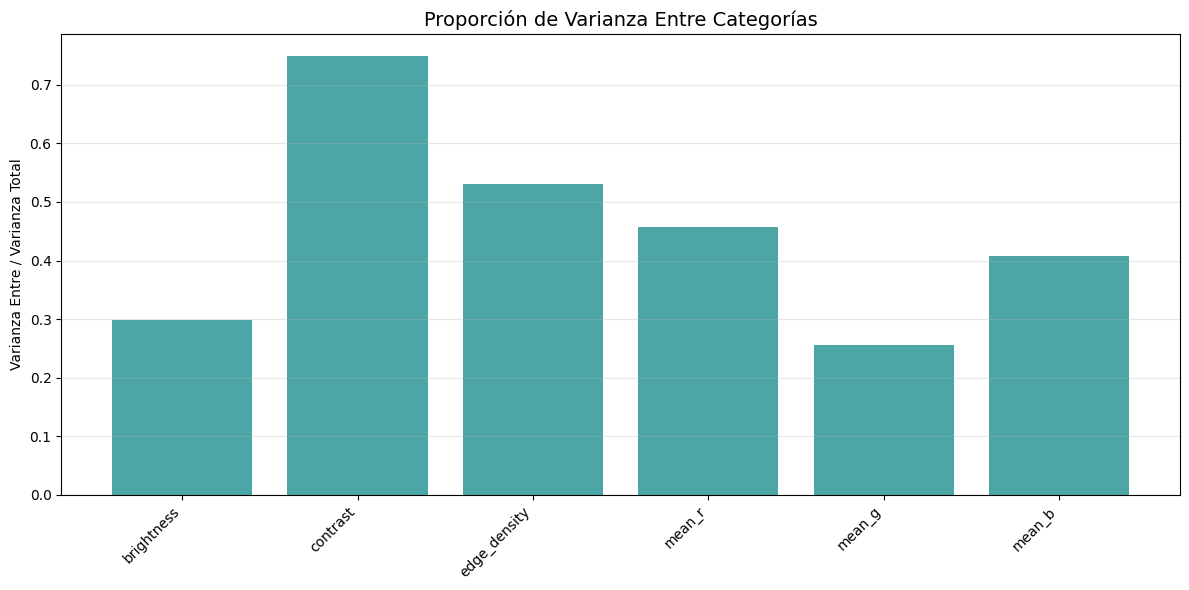

Proporción de varianza entre categorías:
brightness: 0.2993
contrast: 0.7488
edge_density: 0.5313
mean_r: 0.4577
mean_g: 0.2560
mean_b: 0.4073


In [40]:
def analyze_variance_between_categories(image_properties):
    # Creamos DataFrame con propiedades por categoría
    df = pd.DataFrame([{
        'category': p['category'],
        'brightness': p['brightness'],
        'contrast': p['contrast'],
        'edge_density': p['edge_density'],
        'mean_r': p['mean_r'],
        'mean_g': p['mean_g'],
        'mean_b': p['mean_b']
    } for p in image_properties])
    
    # Calculamos medias por categoría
    category_means = df.groupby('category').mean()
    
    # Calculamos varianza explicada entre categorías vs dentro de categorías
    features = ['brightness', 'contrast', 'edge_density', 'mean_r', 'mean_g', 'mean_b']
    
    variance_ratio = {}
    for feature in features:
        # Varianza total
        total_variance = df[feature].var()
        
        # Varianza entre categorías (ponderada por número de muestras)
        between_variance = category_means[feature].var()
        
        # Calculamos proporción de varianza entre categorías
        if total_variance > 0:
            variance_ratio[feature] = between_variance / total_variance
        else:
            variance_ratio[feature] = 0
    
    # Visualizamos resultados
    plt.figure(figsize=(12, 6))
    plt.bar(variance_ratio.keys(), variance_ratio.values(), color='teal', alpha=0.7)
    plt.title('Proporción de Varianza Entre Categorías', fontsize=14)
    plt.ylabel('Varianza Entre / Varianza Total')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return variance_ratio

# Analizamos varianza entre categorías
variance_ratio = analyze_variance_between_categories(image_properties)
print("Proporción de varianza entre categorías:")
for feature, ratio in variance_ratio.items():
    print(f"{feature}: {ratio:.4f}")

## Correlación entre propiedades de imagen

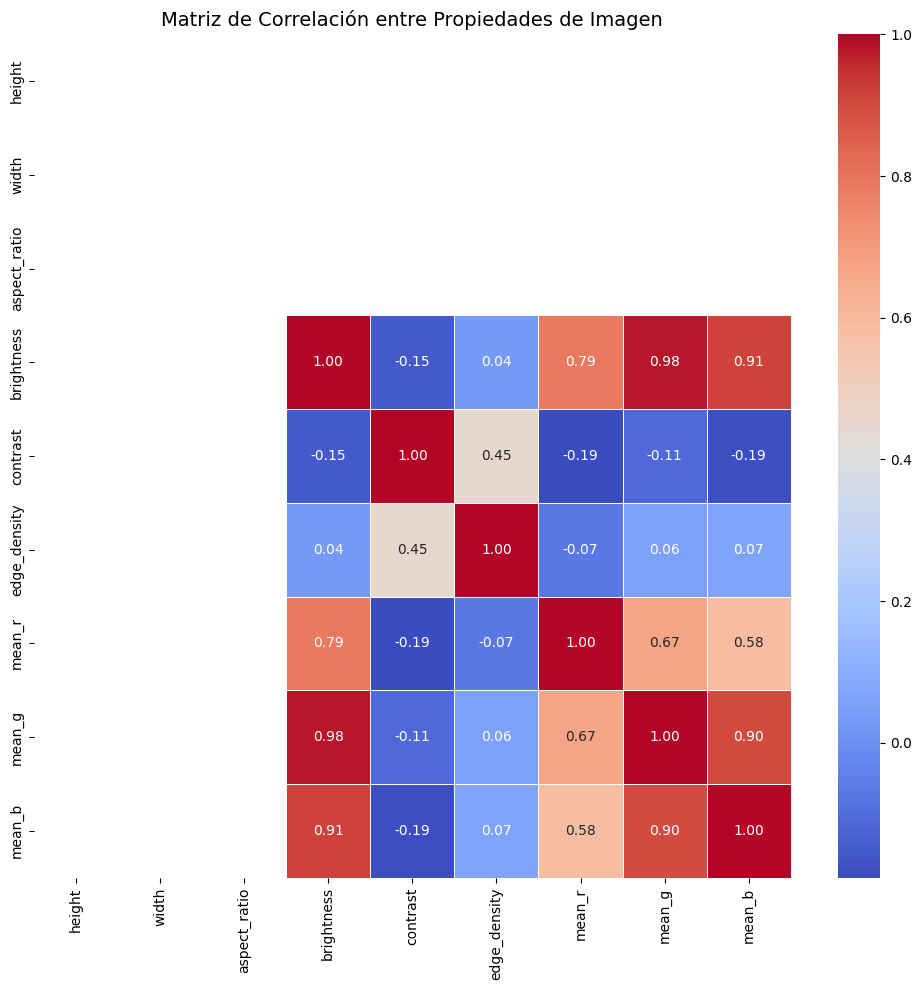

In [43]:
def plot_correlation_matrix(image_properties):
    # Creamos DataFrame con propiedades numéricas
    df = pd.DataFrame([{
        'height': p['height'],
        'width': p['width'],
        'aspect_ratio': p['aspect_ratio'],
        'brightness': p['brightness'],
        'contrast': p['contrast'],
        'edge_density': p['edge_density'],
        'mean_r': p['mean_r'],
        'mean_g': p['mean_g'],
        'mean_b': p['mean_b']
    } for p in image_properties])
    
    # Calculamos matriz de correlación
    corr = df.corr()
    
    # Visualizamos
    plt.figure(figsize=(10, 10))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlación entre Propiedades de Imagen', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return corr

# Visualizamos correlaciones
correlation_matrix = plot_correlation_matrix(image_properties)

## Exploración de muestras atípicas

Detectar imágenes que podrían ser problemáticas

Encontradas 2 imágenes atípicas de 30 (6.67%)


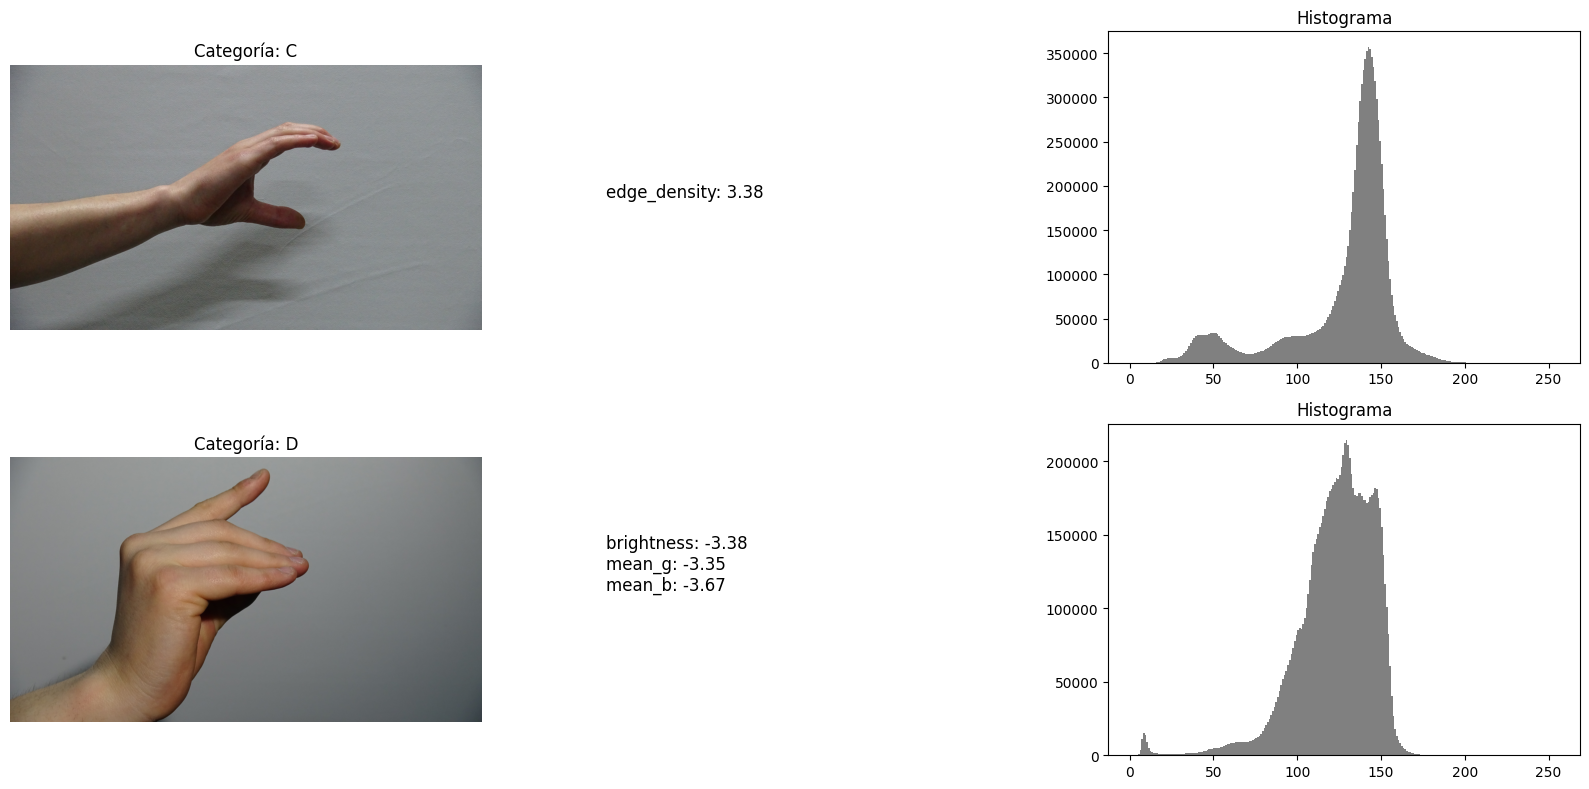

In [44]:
def find_outlier_images(image_properties):
    # Creamos DataFrame con propiedades numéricas
    df = pd.DataFrame([{
        'category': p['category'],
        'file': p['file'],
        'path': p['path'],
        'brightness': p['brightness'],
        'contrast': p['contrast'],
        'edge_density': p['edge_density'],
        'mean_r': p['mean_r'],
        'mean_g': p['mean_g'],
        'mean_b': p['mean_b']
    } for p in image_properties])
    
    # Calculamos los z-scores para detectar outliers
    numerical_features = ['brightness', 'contrast', 'edge_density', 'mean_r', 'mean_g', 'mean_b']
    z_scores = pd.DataFrame()
    
    for feature in numerical_features:
        z_scores[feature] = (df[feature] - df[feature].mean()) / df[feature].std()
    
    # Definimos como outliers aquellos con z-score > 3 en alguna característica
    outlier_mask = (z_scores.abs() > 3).any(axis=1)
    outliers = df[outlier_mask]
    
    print(f"Encontradas {len(outliers)} imágenes atípicas de {len(df)} ({len(outliers)/len(df)*100:.2f}%)")
    
    # Visualizamos algunas imágenes atípicas
    if len(outliers) > 0:
        plt.figure(figsize=(16, 4 * min(4, len(outliers))))
        
        for i, (_, outlier) in enumerate(outliers.iterrows()):
            if i >= 4:  # Limitamos a 4 imágenes
                break
                
            # Buscamos la imagen correspondiente
            img_path = outlier['path']
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                plt.subplot(min(4, len(outliers)), 3, i*3 + 1)
                plt.imshow(img)
                plt.title(f"Categoría: {outlier['category']}")
                plt.axis('off')
                
                # Mostramos características atípicas
                plt.subplot(min(4, len(outliers)), 3, i*3 + 2)
                atypical_features = []
                for feature in numerical_features:
                    z = z_scores.loc[outlier_mask, feature].iloc[i]
                    if abs(z) > 3:
                        atypical_features.append(f"{feature}: {z:.2f}")
                
                plt.text(0.1, 0.5, "\n".join(atypical_features), fontsize=12)
                plt.axis('off')
                
                # Histograma
                plt.subplot(min(4, len(outliers)), 3, i*3 + 3)
                img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                plt.hist(img_gray.ravel(), bins=256, range=(0, 256), color='gray')
                plt.title('Histograma')
                plt.tight_layout()
                
            except Exception as e:
                print(f"Error al procesar {img_path}: {e}")
        
        plt.tight_layout()
        plt.show()
    
    return outliers

# Buscamos imágenes atípicas
outlier_images = find_outlier_images(image_properties)

# Conclusiones

Basado en el análisis del dataset, donde entendimos la estructura y calidad de este dataset, identificamos posibles sesgos, tenemos:

1. Las imágenes ya tienen un tamaño uniforme. No es necesario redimensionar.

2. La variabilidad en brillo y contraste es baja. La normalización es opcional.

3. La distribución de color entre categorías es adecuada

4. Aplicar técnicas de data augmentation para categorías con pocas muestras

5. Realizar detección de anomalías para identificar imágenes problemáticas

6. Considerar extracción de características específicas (bordes, texturas, etc.)

7. Implementar preprocesamiento estándar para redes neuronales:
   - Escalar píxeles al rango [0,1] o [-1,1]